# 03 · Preprocesamiento, ingeniería de variables y split — Etapa ② del pipeline

**Componente del pipeline:** Feature Preprocessing (Cleaning, Normalization, Encoding), incluyendo la **auditoría de fuga de información (leakage)** y el **split temporal con embargo**.

**Entrada:** `data/interim/ingesta.pkl` (salida de `01_ingesta`)
**Salida:** `data/processed/{train,validacion,test}.csv`, `metadata_preparacion.json`, `diccionario_variables.csv`, `auditoria_leakage.csv`

In [ ]:
import sys; sys.path.append("..")
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from src.paths import RAW, INTERIM, PROCESSED

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paleta categórica validada (orden fijo, apta para daltonismo) y tinta neutra
C1, C2, C3, C4, C5, C6, C7, C8 = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                                  "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
PALETTE = [C1, C2, C3, C4, C5, C6, C7, C8]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "lines.linewidth": 2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
DATA_DIR = RAW
print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| numpy", np.__version__)

In [ ]:
# Datos de la etapa de ingesta (01_ingesta.ipynb)
df = pd.read_pickle(INTERIM / "ingesta.pkl")
N_PERIODS = 20
EXPIRED_HOSPICE = [11, 13, 14, 19, 20, 21]
NUM_RAW = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
           "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
MED_COLS = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide",
            "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol",
            "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]

# PSI: reutilizadas en la validación del split y la auditoría de drift (definidas en el EDA)
def psi_numeric(ref, cur, bins=10, eps=1e-4):
    edges = np.unique(np.quantile(ref.dropna(), np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(ref.dropna(), edges)[0] / ref.notna().sum()
    c = np.histogram(cur.dropna(), edges)[0] / cur.notna().sum()
    r, c = np.clip(r, eps, None), np.clip(c, eps, None)
    return float(np.sum((c - r) * np.log(c / r)))

def psi_categorical(ref, cur, eps=1e-4):
    r = ref.fillna("Missing").value_counts(normalize=True)
    c = cur.fillna("Missing").value_counts(normalize=True)
    idx = r.index.union(c.index)
    r, c = r.reindex(idx, fill_value=0).clip(eps), c.reindex(idx, fill_value=0).clip(eps)
    return float(np.sum((c - r) * np.log(c / r)))

## 7. Preprocesamiento

En resumen estas fueron las decisioens que tomamos y el porque de estas deciciones luego de realizar el EDA en todo el dataset
| Decisión | Justificación |
|---|---|
| Excluir altas por fallecimiento/hospicio y sexo inválido | No pueden reingresar / registro inválido (Sección 1) |
| Eliminar `weight`, `examide`, `citoglipton` | 97 % faltante / constantes |
| Eliminar `payer_code` | Drift de registro extremo (PSI > 0.25): de 100 % faltante a mayoritariamente registrado; asociación débil con el objetivo. Aprendería un artefacto del sistema de información |
| Faltantes categóricos → `Missing` | Faltante no aleatorio e informativo |
| IDs de admisión/alta/fuente → grupos clínicos | Reduce cardinalidad y agrupa faltantes ocultos |
| Diagnósticos ICD-9 → 9 grupos (Strack et al., 2014) | ~700 códigos → grupos clínicos interpretables |
| `medical_specialty` → top-15 **del train** + `Other` | Evita categorías raras y fuga (se aprende solo del pasado) |
| `age` → punto medio numérico | Preserva el orden |
| `number_diagnoses` → recortado a 9 | Armoniza el cambio de régimen de codificación (Sección 4.3) |
| `log1p` + estandarización (solo modelo lineal) | Conteos muy asimétricos |
| Medicamentos raros (< 1 % de uso) → solo en conteos agregados | Evita columnas casi constantes |

Todo lo que **aprende de los datos** (top de especialidades, imputación, escalado, codificación) se ajusta **solo con el conjunto de entrenamiento**.

In [27]:
data = df[~df.discharge_disposition_id.isin(EXPIRED_HOSPICE) & (df.gender != "Unknown/Invalid")].copy()
data = data.drop(columns=["weight", "examide", "citoglipton", "payer_code", "anomaly_score", "is_anomaly"], errors="ignore")
MEDS = [c for c in MED_COLS if c in data.columns]
print(f"Encuentros tras limpieza: {len(data):,} ({len(data) / len(df):.1%} del total) | tasa <30: {data.target.mean():.2%}")

def map_groups(s, groups, default="Other"):
    lookup = {code: name for name, codes in groups.items() for code in codes}
    return s.map(lookup).fillna(default)

ADM_TYPE_GROUPS = {"Emergency/Urgent": [1, 2, 7], "Elective": [3], "Unknown": [5, 6, 8]}
DISCHARGE_GROUPS = {"Home": [1], "Home health": [6, 8], "SNF/long-term": [3, 4, 5, 15, 22, 23, 24, 27, 29, 30],
                    "Other hospital": [2, 9, 10, 16, 17, 28], "Left AMA": [7], "Unknown": [18, 25, 26]}
ADM_SOURCE_GROUPS = {"Referral": [1, 2, 3], "Emergency room": [7], "Transfer": [4, 5, 6, 10, 18, 22, 25, 26],
                     "Unknown": [9, 15, 17, 20, 21]}

def icd9_group(code):
    if pd.isna(code):
        return "Missing"
    if code[0] in "VE":
        return "Other"
    v = float(code)
    if 390 <= v < 460 or int(v) == 785: return "Circulatory"
    if 460 <= v < 520 or int(v) == 786: return "Respiratory"
    if 520 <= v < 580 or int(v) == 787: return "Digestive"
    if int(v) == 250: return "Diabetes"
    if 800 <= v < 1000: return "Injury"
    if 710 <= v < 740: return "Musculoskeletal"
    if 580 <= v < 630 or int(v) == 788: return "Genitourinary"
    if 140 <= v < 240: return "Neoplasms"
    return "Other"

data["admission_type_grp"] = map_groups(data.admission_type_id, ADM_TYPE_GROUPS)
data["discharge_grp"] = map_groups(data.discharge_disposition_id, DISCHARGE_GROUPS)
data["admission_source_grp"] = map_groups(data.admission_source_id, ADM_SOURCE_GROUPS)
for i in (1, 2, 3):
    data[f"diag_{i}_grp"] = data[f"diag_{i}"].map(icd9_group)
data["race"] = data.race.fillna("Missing")
data["medical_specialty"] = data.medical_specialty.fillna("Missing")
data["age_num"] = data.age.str.extract(r"\[(\d+)-")[0].astype(int) + 5
data["number_diagnoses_capped"] = data.number_diagnoses.clip(upper=9)

data[["admission_type_grp", "discharge_grp", "admission_source_grp", "diag_1_grp"]].apply(
    lambda s: s.value_counts(normalize=True).round(3).to_dict())

Encuentros tras limpieza: 99,340 (97.6% del total) | tasa <30: 11.39%


admission_type_grp      {'Emergency/Urgent': 0.71, 'Elective': 0.188, ...
discharge_grp           {'Home': 0.606, 'SNF/long-term': 0.186, 'Home ...
admission_source_grp    {'Emergency room': 0.562, 'Referral': 0.306, '...
diag_1_grp              {'Circulatory': 0.299, 'Other': 0.179, 'Respir...
dtype: object

## 8. Feature engineering

Tres familias de variables, **todas disponibles al momento del alta**:

1. **Estáticas del encuentro** (derivadas clínicas): utilización de servicios, carga de medicación, comorbilidades.
2. **Temporales por paciente (variables rezagadas / lags):** historial del mismo paciente usando **solo encuentros anteriores** (`shift`, sumas acumuladas y ventanas de los últimos 3 encuentros).
3. **Agregaciones por ventana deslizante (contexto del periodo):** tasas y medias recientes en los últimos 3 000 encuentros, con **embargo por latencia de etiqueta** para las variables que usan el objetivo.

**Latencia de etiqueta.** Si los encuentros se repartieran de forma uniforme habría ≈ 28 encuentros/día (101 766 en ~10 años), y 30 días serían ≈ 840 encuentros; la hipótesis inicial era un embargo de `LABEL_DELAY_NAIVE = 1 000` encuentros (≈ 36 días). La densidad de encuentros **no es constante**, así que el embargo se **calibra empíricamente solo con los periodos de train** a partir de la distancia a la que el siguiente encuentro del paciente deja de ser un reingreso <30 (evidencia y validación en la **Sección 10.3**). Una etiqueta solo se considera conocida `LABEL_DELAY` posiciones después.

**¿El lag de reingreso previo es fuga?** No: si el encuentro anterior del paciente terminó en reingreso <30, ese hecho ya ocurrió (y es observable) cuando el paciente vuelve a ser admitido en el encuentro actual.

In [28]:
LABEL_DELAY_NAIVE = 1000   # hipótesis inicial: ≈ 28 encuentros/día × 36 días (densidad constante)
CTX_W = 3000
data = data.sort_values("t_idx").reset_index(drop=True)

# ---- 0) Calibración empírica de la latencia de etiqueta (evidencia en la Sección 10.3) ----
def next_gap(d):
    # Distancia en pseudo-tiempo al siguiente encuentro del mismo paciente (NaN si no vuelve)
    return d.groupby("patient_nbr", sort=False)["t_idx"].shift(-1) - d.t_idx

def readmission_boundary(gap, y, thr=0.2, step=100, min_gap=500):
    # Equivalente de "30 días" en encuentros: primer tramo de distancia donde P(target=1 | gap) < thr
    rate = y.groupby((gap // step) * step).mean()
    rate = rate[(rate.index >= min_gap) & (rate < thr)]
    return float(rate.index.min()) if len(rate) else np.nan

d_cal = data[data.period <= 11]            # solo periodos de train: el parámetro no mira el futuro
gap_cal = next_gap(d_cal)
delay_by_period = pd.Series({p: readmission_boundary(gap_cal[d_cal.period == p], d_cal.target[d_cal.period == p])
                             for p in range(12)})
LABEL_DELAY = int(np.ceil(delay_by_period.max() / 500) * 500)   # máximo en train, redondeado hacia arriba
print(f"Equivalente de 30 días por periodo de train: {delay_by_period.astype(int).to_dict()}")
print(f"LABEL_DELAY calibrado = {LABEL_DELAY:,} encuentros (hipótesis inicial: {LABEL_DELAY_NAIVE:,})")

# ---- 1) Estáticas ----
data["service_utilization"] = data.number_outpatient + data.number_emergency + data.number_inpatient
data["n_meds_active"] = (data[MEDS] != "No").sum(axis=1)
data["n_meds_changed"] = data[MEDS].isin(["Up", "Down"]).sum(axis=1)
data["meds_per_day"] = data.num_medications / data.time_in_hospital
data["labs_per_day"] = data.num_lab_procedures / data.time_in_hospital
diag_grps = data[["diag_1_grp", "diag_2_grp", "diag_3_grp"]]
data["n_comorbidity_groups"] = diag_grps.apply(lambda r: len(set(r) - {"Missing", "Other"}), axis=1)
data["dm_primary"] = (data.diag_1_grp == "Diabetes").astype(int)
diag_str = data[["diag_1", "diag_2", "diag_3"]].fillna("")
data["dm_complicated"] = diag_str.apply(lambda c: c.str.match(r"^250\.[1-9]")).any(axis=1).astype(int)
data["a1c_tested"] = (data.A1Cresult != "None").astype(int)
data["a1c_high"] = data.A1Cresult.isin([">7", ">8"]).astype(int)
data["glu_tested"] = (data.max_glu_serum != "None").astype(int)
data["glu_high"] = data.max_glu_serum.isin([">200", ">300"]).astype(int)

# ---- 2) Temporales por paciente (solo pasado) ----
g = data.groupby("patient_nbr", sort=False)
data["enc_seq"] = g.cumcount()
data["is_returning"] = (data.enc_seq > 0).astype(int)
data["prev_readmit30"] = g["target"].shift(1).fillna(0)
data["hist_n_readmit30"] = g["target"].cumsum() - data.target
data["hist_rate_readmit30"] = np.where(data.enc_seq > 0, data.hist_n_readmit30 / data.enc_seq.clip(lower=1), 0)
for col in ["time_in_hospital", "num_medications", "number_diagnoses_capped", "n_meds_active"]:
    data[f"prev_{col}"] = g[col].shift(1)
data["delta_num_medications"] = (data.num_medications - data.prev_num_medications).fillna(0)
data["delta_n_meds_active"] = (data.n_meds_active - data.prev_n_meds_active).fillna(0)
lags = np.column_stack([g["time_in_hospital"].shift(k) for k in (1, 2, 3)])
data["roll3_time_in_hospital"] = np.nanmean(np.where(np.isnan(lags), np.nan, lags), axis=1)
data["log_gap_prev_encounter"] = np.log1p(data.t_idx - g["t_idx"].shift(1))  # distancia en pseudo-tiempo
data["prev_discharge_snf"] = g["discharge_grp"].shift(1).eq("SNF/long-term").astype(int)

# ---- 3) Agregaciones por ventana deslizante (contexto) ----
data["ctx_readmit_rate"] = data.target.shift(LABEL_DELAY).rolling(CTX_W, min_periods=500).mean()  # con embargo
data["ctx_inpatient_mean"] = data.number_inpatient.shift(1).rolling(CTX_W, min_periods=500).mean()
data["ctx_a1c_rate"] = data.a1c_tested.shift(1).rolling(CTX_W, min_periods=500).mean()
ctx_ndiag = data.number_diagnoses.shift(1).rolling(CTX_W, min_periods=500).mean()
ctx_nmed = data.num_medications.shift(1).rolling(CTX_W, min_periods=500).mean()
data["rel_number_diagnoses"] = data.number_diagnoses - ctx_ndiag       # relativo al régimen de codificación vigente
data["rel_num_medications"] = data.num_medications - ctx_nmed         # relativo a la práctica reciente

TEMPORAL_FEATS = ["enc_seq", "is_returning", "prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30",
                  "prev_time_in_hospital", "prev_num_medications", "prev_number_diagnoses_capped",
                  "prev_n_meds_active", "delta_num_medications", "delta_n_meds_active", "roll3_time_in_hospital",
                  "log_gap_prev_encounter", "prev_discharge_snf"]
CONTEXT_FEATS = ["ctx_readmit_rate", "ctx_inpatient_mean", "ctx_a1c_rate", "rel_number_diagnoses", "rel_num_medications"]
print(f"Pacientes con historial previo: {data.is_returning.mean():.1%} de los encuentros")
data[TEMPORAL_FEATS + CONTEXT_FEATS].describe().T

Equivalente de 30 días por periodo de train: {0: 900, 1: 1000, 2: 900, 3: 900, 4: 1000, 5: 900, 6: 1000, 7: 800, 8: 1300, 9: 1500, 10: 1600, 11: 1700}
LABEL_DELAY calibrado = 2,000 encuentros (hipótesis inicial: 1,000)


Pacientes con historial previo: 29.5% de los encuentros


,count,mean,std,min,25%,50%,75%,max
enc_seq,"99,340.0000",0.6254,1.5269,0.0000,0.0000,0.0000,1.0000,39.0000
is_returning,"99,340.0000",0.2955,0.4563,0.0000,0.0000,0.0000,1.0000,1.0000
prev_readmit30,"99,340.0000",0.0790,0.2697,0.0000,0.0000,0.0000,0.0000,1.0000
hist_n_readmit30,"99,340.0000",0.1855,0.7185,0.0000,0.0000,0.0000,0.0000,22.0000
hist_rate_readmit30,"99,340.0000",0.0775,0.2357,0.0000,0.0000,0.0000,0.0000,1.0000
prev_time_in_hospital,"29,353.0000",4.5632,2.9831,1.0000,2.0000,4.0000,6.0000,14.0000
prev_num_medications,"29,353.0000",16.3694,7.7302,1.0000,11.0000,15.0000,20.0000,72.0000
prev_number_diagnoses_capped,"29,353.0000",7.6183,1.8119,1.0000,6.0000,9.0000,9.0000,9.0000
prev_n_meds_active,"29,353.0000",1.2068,0.8956,0.0000,1.0000,1.0000,2.0000,6.0000
delta_num_medications,"99,340.0000",0.1057,4.8807,-59.0000,0.0000,0.0000,0.0000,59.0000


In [29]:
# Verificación anti-fuga: las variables rezagadas no deben depender de encuentros futuros.
# Se recalculan truncando los datos en un punto y deben coincidir exactamente con el cálculo completo.
cut = int(len(data) * 0.5)
trunc = data.iloc[:cut].copy()
gt = trunc.groupby("patient_nbr", sort=False)
check = pd.DataFrame({
    "enc_seq": gt.cumcount(),
    "hist_n_readmit30": gt["target"].cumsum() - trunc.target,
    "prev_readmit30": gt["target"].shift(1).fillna(0),
})
ok = all(np.allclose(check[c].values, data.iloc[:cut][c].values) for c in check)
print("Variables rezagadas idénticas con datos truncados (sin fuga del futuro):", ok)

Variables rezagadas idénticas con datos truncados (sin fuga del futuro): True


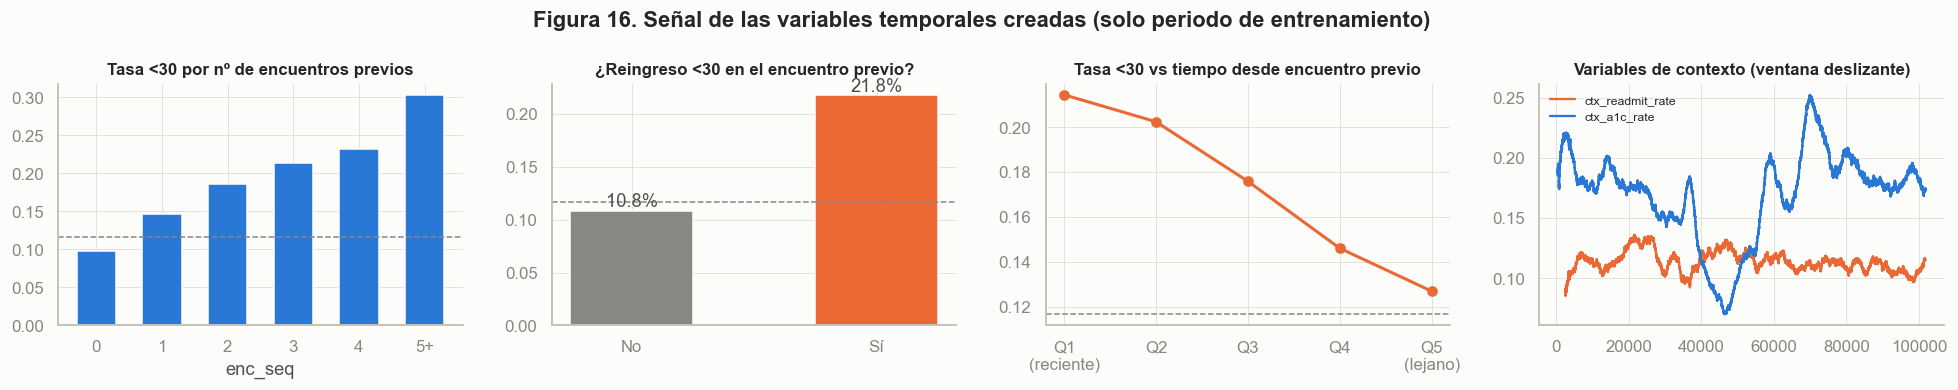

,AUC_univariado(|·|)
service_utilization,0.6051
enc_seq,0.5733
is_returning,0.5677
rel_number_diagnoses,0.5555
hist_n_readmit30,0.5515
hist_rate_readmit30,0.5498
rel_num_medications,0.5486
prev_readmit30,0.5378
log_gap_prev_encounter,0.5306
n_meds_changed,0.5253


In [30]:
FE_EVAL = data.period <= 11   # la exploración de nuevas variables usa solo el periodo de entrenamiento
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
d_ = data[FE_EVAL]
t1 = d_.groupby(d_.enc_seq.clip(upper=5))["target"].agg(["mean", "size"])
axes[0].bar([str(i) if i < 5 else "5+" for i in t1.index], t1["mean"], color=C1, width=0.6)
axes[0].set_title("Tasa <30 por nº de encuentros previos"); axes[0].set_xlabel("enc_seq")
t2 = d_.groupby("prev_readmit30")["target"].mean()
b = axes[1].bar(["No", "Sí"], t2.values, color=[MUTED, C2], width=0.5)
axes[1].bar_label(b, labels=[f"{v:.1%}" for v in t2.values], color=INK2)
axes[1].set_title("¿Reingreso <30 en el encuentro previo?")
t3 = d_[d_.is_returning == 1].groupby(pd.qcut(d_.loc[d_.is_returning == 1, "log_gap_prev_encounter"], 5))["target"].mean()
axes[2].plot(range(5), t3.values, color=C2, marker="o")
axes[2].set_xticks(range(5), ["Q1\n(reciente)", "Q2", "Q3", "Q4", "Q5\n(lejano)"])
axes[2].set_title("Tasa <30 vs tiempo desde encuentro previo")
axes[3].plot(data.t_idx, data.ctx_readmit_rate, color=C2, lw=1.5, label="ctx_readmit_rate")
axes[3].plot(data.t_idx, data.ctx_a1c_rate, color=C1, lw=1.5, label="ctx_a1c_rate")
axes[3].set_title("Variables de contexto (ventana deslizante)"); axes[3].legend(fontsize=8)
for ax in axes[:3]:
    ax.axhline(d_.target.mean(), color=MUTED, ls="--", lw=1)
fig.suptitle("Figura 16. Señal de las variables temporales creadas (solo periodo de entrenamiento)", fontweight="bold")
plt.tight_layout(); plt.show()

new_feats = ["service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "n_comorbidity_groups",
             "dm_complicated", "a1c_tested"] + TEMPORAL_FEATS + CONTEXT_FEATS
fe_signal = pd.Series({c: roc_auc_score(d_.target, d_[c].fillna(d_[c].median())) for c in new_feats})
fe_signal = (fe_signal - 0.5).abs().add(0.5).sort_values(ascending=False).rename("AUC_univariado(|·|)")
fe_signal.to_frame().head(15)

## 9. División temporal de los datos

| Conjunto | Periodos | Uso |
|---|---|---|
| **Train** | 0–11 (60 %) | Ajuste de modelos y de todo el preprocesamiento |
| **Validación** | 12–15 (20 %) | Selección de hiperparámetros, umbral y calibración |
| **Test** | 16–19 (20 %) | Evaluación final, una sola vez, en el futuro "no visto" |

**Embargo:** se eliminan los últimos `LABEL_DELAY` encuentros de train y de validación, porque sus etiquetas (reingreso en los 30 días siguientes) aún no serían observables al momento del corte. 
**No se usa `shuffle` ni validación cruzada aleatoria**, que mezclaría futuro y pasado. (se realiza esto para evitar colocar accidentalemnte un paciente en trian y test)

,n,% del total,tasa <30,t_idx inicio,t_idx fin,% pacientes vistos en train
train,"57,709.0000",58.0924,0.1167,0.0000,"59,059.0000",100.0000
validación,"17,912.0000",18.0310,0.1110,"61,060.0000","79,412.0000",20.9915
test,"19,830.0000",19.9617,0.1087,"81,413.0000","101,765.0000",10.9481
embargo (descartado),"3,889.0000",3.9148,0.1119,"59,060.0000","81,412.0000",23.1936


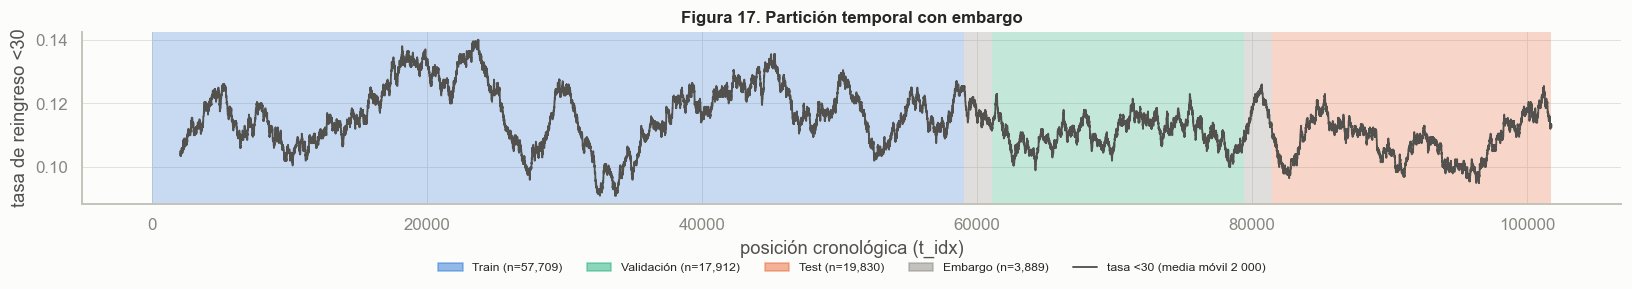

In [31]:
TRAIN_P, VAL_P, TEST_P = list(range(0, 12)), list(range(12, 16)), list(range(16, 20))
val_start = data.loc[data.period.isin(VAL_P), "t_idx"].min()
test_start = data.loc[data.period.isin(TEST_P), "t_idx"].min()

def split_masks(delay):
    m_tr = data.period.isin(TRAIN_P) & (data.t_idx < val_start - delay)
    m_va = data.period.isin(VAL_P) & (data.t_idx < test_start - delay)
    m_te = data.period.isin(TEST_P)
    return m_tr, m_va, m_te, ~(m_tr | m_va | m_te)

m_train, m_val, m_test, m_embargo = split_masks(LABEL_DELAY)

# Especialidades más frecuentes: se aprenden SOLO del train
TOP_SPEC = data.loc[m_train, "medical_specialty"].value_counts().head(15).index
data["specialty_grp"] = data.medical_specialty.where(data.medical_specialty.isin(TOP_SPEC), "Other")

train_pat = set(data.loc[m_train, "patient_nbr"])
split_tbl = pd.DataFrame({
    name: {"n": m.sum(), "% del total": m.mean() * 100, "tasa <30": data.loc[m, "target"].mean(),
           "t_idx inicio": data.loc[m, "t_idx"].min(), "t_idx fin": data.loc[m, "t_idx"].max(),
           "% pacientes vistos en train": data.loc[m, "patient_nbr"].isin(train_pat).mean() * 100}
    for name, m in [("train", m_train), ("validación", m_val), ("test", m_test), ("embargo (descartado)", m_embargo)]
}).T
display(split_tbl)
assert data.loc[m_train, "t_idx"].max() < data.loc[m_val, "t_idx"].min() < data.loc[m_test, "t_idx"].min()

fig, ax = plt.subplots(figsize=(15, 3))
seg = [(m_train, C1, "Train"), (m_val, C3, "Validación"), (m_test, C2, "Test"), (m_embargo, MUTED, "Embargo")]
handles = []
for m, c, lab in seg:
    idx = data.loc[m, "t_idx"].values
    # bloques contiguos de t_idx
    breaks = np.where(np.diff(idx) > LABEL_DELAY // 2)[0]
    for s, e in zip(np.r_[0, breaks + 1], np.r_[breaks, len(idx) - 1]):
        ax.axvspan(idx[s], idx[e], color=c, alpha=0.25, lw=0)
    handles.append(mpatches.Patch(color=c, alpha=0.5, label=f"{lab} (n={m.sum():,})"))
ax.plot(data.t_idx, data.target.rolling(2000).mean(), color=INK2, lw=1.2)
handles.append(plt.Line2D([], [], color=INK2, lw=1.2, label="tasa <30 (media móvil 2 000)"))
ax.set_ylabel("tasa de reingreso <30"); ax.set_xlabel("posición cronológica (t_idx)")
ax.legend(handles=handles, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.28), fontsize=8)
ax.set_title("Figura 17. Partición temporal con embargo")
plt.tight_layout(); plt.show()

Hemos optado por no usar la variable race debido a restricciones éticas

In [32]:
# `race` NO se usa como predictor (restricción ética: no usar raza para priorizar pacientes): se conserva solo para auditar equidad
CAT_FEATS = ["gender","admission_type_grp", "discharge_grp", "admission_source_grp", "specialty_grp",
             "diag_1_grp", "diag_2_grp", "diag_3_grp", "max_glu_serum", "A1Cresult", "insulin", "metformin",
             "glipizide", "glyburide", "pioglitazone", "rosiglitazone", "glimepiride", "change", "diabetesMed"]
STATIC_NUM = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
              "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses_capped",
              "service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "labs_per_day",
              "n_comorbidity_groups", "dm_primary", "dm_complicated", "a1c_tested", "a1c_high", "glu_tested", "glu_high"]

NUM_FEATS = STATIC_NUM + TEMPORAL_FEATS
FEATURES = NUM_FEATS + CAT_FEATS
print(f"{len(FEATURES)} variables finales: {len(STATIC_NUM)} numéricas estáticas, {len(TEMPORAL_FEATS)} temporales por paciente, "
      f"{len(CAT_FEATS)} categóricas (+{len(CONTEXT_FEATS)} de contexto opcionales)")

X_train, y_train = data.loc[m_train, FEATURES], data.loc[m_train, "target"]
X_val, y_val = data.loc[m_val, FEATURES], data.loc[m_val, "target"]
X_test, y_test = data.loc[m_test, FEATURES], data.loc[m_test, "target"]

psi_split = pd.Series({c: (psi_categorical if c in CAT_FEATS else psi_numeric)(data.loc[m_train, c], data.loc[m_test, c])
                       for c in FEATURES + CONTEXT_FEATS})
psi_split.sort_values(ascending=False).head(10).rename("PSI train→test").to_frame()

54 variables finales: 21 numéricas estáticas, 14 temporales por paciente, 19 categóricas (+5 de contexto opcionales)


,PSI train→test
ctx_inpatient_mean,3.9235
ctx_a1c_rate,3.5690
rel_number_diagnoses,3.3625
ctx_readmit_rate,3.3119
specialty_grp,0.6631
log_gap_prev_encounter,0.4764
discharge_grp,0.3830
number_diagnoses_capped,0.3303
admission_source_grp,0.2843
prev_number_diagnoses_capped,0.2637


## 10. Detección de *data leakage*

Hay **fuga de información** cuando el modelo aprende de datos que **no existirán en el momento de predecir**. Da métricas excelentes en validación y luego falla en producción. En este proyecto el momento de predicción es **el alta hospitalaria** del encuentro actual. Por eso toda variable debe conocerse en ese instante, y el entrenamiento solo puede usar etiquetas que ya fueran observables en la fecha de corte.

Se auditan cinco tipos de fuga:

| Tipo | Pregunta | Prueba |
|---|---|---|
| Fuga de objetivo | ¿Alguna variable se genera después del alta o es un reflejo de `readmitted`? | 10.1 disponibilidad temporal · 10.2 cribado de señal |
| Fuga temporal (latencia de etiqueta) | ¿Se entrena con etiquetas que aún no se habrían observado? | 10.3 calibración del embargo |
| Contaminación entre conjuntos | ¿Train y test comparten filas o pacientes de forma que el modelo memorice? | 10.4 |
| Fuga en el pipeline | ¿El modelo encuentra señal donde no debería haberla? | 10.5 etiquetas permutadas, ablación, importancias |
| Fuga por decisiones del analista | ¿Alguna decisión de preprocesamiento se tomó mirando el test? | 10.6 |

### 10.1 Auditoría de disponibilidad temporal

In [33]:
AT_ADMISSION = ["age_num", "gender", "admission_type_grp", "admission_source_grp", "number_outpatient",
                "number_emergency", "number_inpatient", "service_utilization"]
LABEL_FEATS = ["prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30"]   # usan la etiqueta de encuentros previos
ALL_FEATS = FEATURES + CONTEXT_FEATS
FORBIDDEN = {"readmitted", "target", "encounter_id", "patient_nbr", "t_idx", "period", "race"}

def availability(c):
    if c in LABEL_FEATS:
        return "Historial (etiquetas previas)", "Sí", "Etiqueta de encuentros anteriores: el reingreso ya ocurrió al volver el paciente"
    if c == "ctx_readmit_rate":
        return "Contexto (ventana pasada)", "Sí", f"Embargo de LABEL_DELAY = {LABEL_DELAY:,} encuentros"
    if c in TEMPORAL_FEATS:
        return "Historial (encuentros previos)", "No", "Solo shift / cumsum hacia atrás (prueba de truncamiento)"
    if c in CONTEXT_FEATS:
        return "Contexto (ventana pasada)", "No", "shift(1) antes de la ventana deslizante"
    if c in AT_ADMISSION:
        return "Ingreso", "No", "Conocida al admitir al paciente"
    return "Alta", "No", "Registrada durante la estancia o al alta"

avail = pd.DataFrame([availability(c) for c in ALL_FEATS], index=pd.Index(ALL_FEATS, name="variable"),
                     columns=["momento_disponible", "usa_etiqueta", "control_anti_fuga"])
print("Columnas prohibidas entre los predictores:", sorted(FORBIDDEN & set(ALL_FEATS)) or "ninguna")
display(avail.groupby(["momento_disponible", "usa_etiqueta"]).size().rename("n_variables").to_frame())
avail[avail.usa_etiqueta == "Sí"]

Columnas prohibidas entre los predictores: ninguna


n_variables
momento_disponible             usa_etiqueta             
Alta                           No                     32
Contexto (ventana pasada)      No                      4
                               Sí                      1
Historial (encuentros previos) No                     11
Historial (etiquetas previas)  Sí                      3
Ingreso                        No                      8

,momento_disponible,usa_etiqueta,control_anti_fuga
variable,,,
prev_readmit30,Historial (etiquetas previas),Sí,Etiqueta de encuentros anteriores: el reingres...
hist_n_readmit30,Historial (etiquetas previas),Sí,Etiqueta de encuentros anteriores: el reingres...
hist_rate_readmit30,Historial (etiquetas previas),Sí,Etiqueta de encuentros anteriores: el reingres...
ctx_readmit_rate,Contexto (ventana pasada),Sí,"Embargo de LABEL_DELAY = 2,000 encuentros"


**Resultado:**
- Ninguna variable se genera **después del alta**, y ni `readmitted`, ni los identificadores, ni el eje temporal (`t_idx`, `period`) ni `race` están entre los predictores.
- Las 4 variables que usan la etiqueta miran solo el **pasado**. Si el encuentro previo terminó en reingreso <30, ese reingreso ya ocurrió (muchas veces es el propio encuentro actual), así que es observable. `ctx_readmit_rate` usa etiquetas con embargo.
- ⚠️ Esto vale para una predicción **al alta**. Si el sistema se usara **al ingreso**, `discharge_grp`, `time_in_hospital`, los conteos de procedimientos, laboratorio y medicamentos, los diagnósticos y los cambios de medicación serían fuga y habría que excluirlos.

### 10.2 Cribado de variables "demasiado buenas" e identificadores
Una variable con fuga suele separar el objetivo casi por sí sola. Se calcula el AUC univariado de cada variable **en train**. En las categóricas se usa la tasa de reingreso por categoría, que es una cota superior de su señal. También se buscan categorías con separación perfecta y se comprueba que los identificadores no predicen el objetivo.

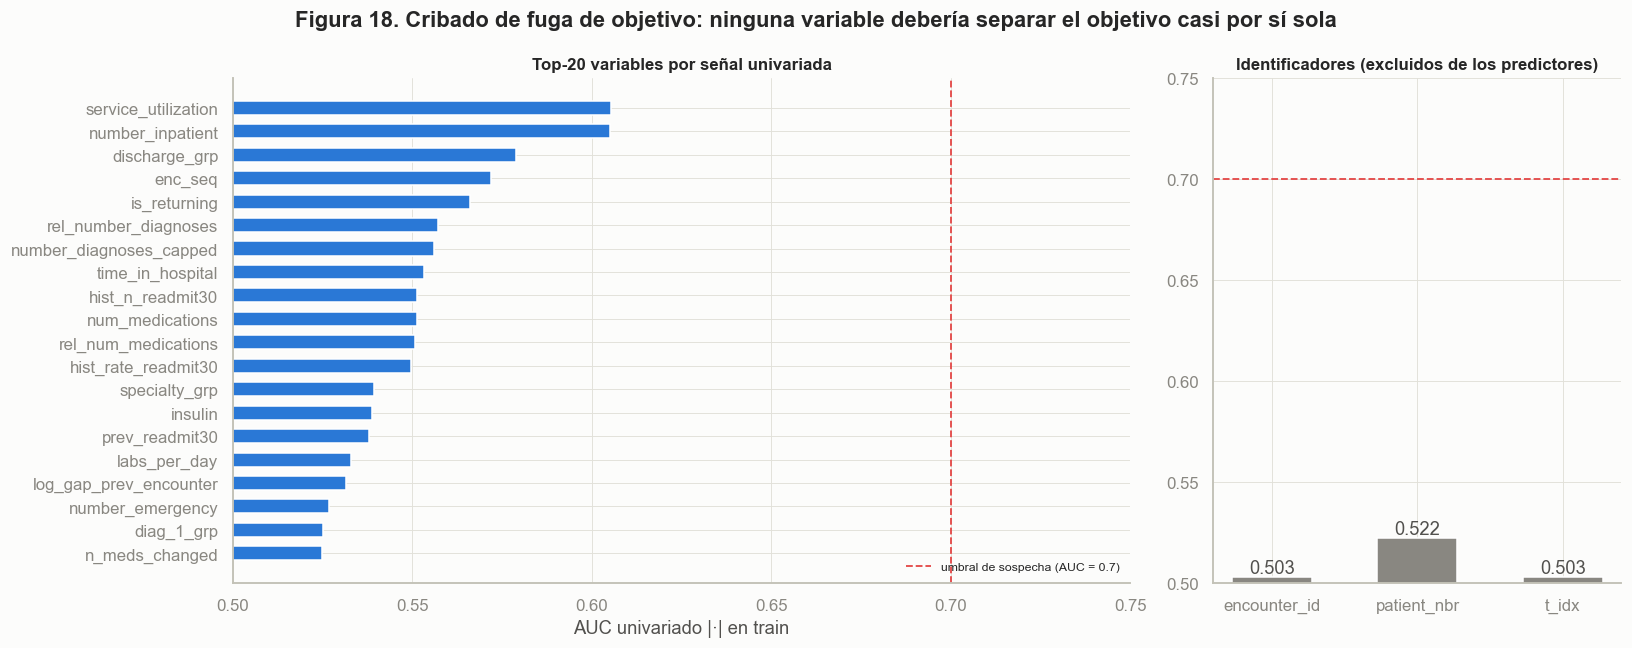

Variables con AUC univariado > 0.7: ninguna
Categorías (n ≥ 30) con separación perfecta del objetivo: ninguna


In [34]:
d_tr = data[m_train]

def auc_sym(y, x):
    a = roc_auc_score(y, x)
    return max(a, 1 - a)

LEAK_AUC = 0.70   # ninguna variable aislada debería acercarse al desempeño de un modelo completo
id_auc = pd.Series({c: auc_sym(d_tr.target, d_tr[c]) for c in ["encounter_id", "patient_nbr", "t_idx"]})
screen = pd.Series({c: auc_sym(d_tr.target, d_tr[c].fillna(d_tr[c].median())) for c in NUM_FEATS + CONTEXT_FEATS})
for c in CAT_FEATS:
    screen[c] = auc_sym(d_tr.target, d_tr.groupby(c)["target"].transform("mean"))
screen = screen.sort_values(ascending=False)
cat_rates = [(c, k, int(r["size"])) for c in CAT_FEATS
             for k, r in d_tr.groupby(c)["target"].agg(["mean", "size"]).iterrows()
             if r["size"] >= 30 and r["mean"] in (0, 1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2.2, 1]})
top = screen.head(20)[::-1]
axes[0].barh(top.index, top.values, color=[C8 if v > LEAK_AUC else C1 for v in top.values], height=0.6)
axes[0].axvline(LEAK_AUC, color=C8, ls="--", lw=1.2, label=f"umbral de sospecha (AUC = {LEAK_AUC})")
axes[0].set_xlim(0.5, max(LEAK_AUC + 0.05, top.max() + 0.02)); axes[0].set_xlabel("AUC univariado |·| en train")
axes[0].set_title("Top-20 variables por señal univariada"); axes[0].legend(fontsize=8, loc="lower right")
b = axes[1].bar(id_auc.index, id_auc.values, color=MUTED, width=0.55)
axes[1].bar_label(b, fmt="%.3f", color=INK2)
axes[1].axhline(LEAK_AUC, color=C8, ls="--", lw=1.2); axes[1].set_ylim(0.5, LEAK_AUC + 0.05)
axes[1].set_title("Identificadores (excluidos de los predictores)")
fig.suptitle("Figura 18. Cribado de fuga de objetivo: ninguna variable debería separar el objetivo casi por sí sola",
             fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Variables con AUC univariado > {LEAK_AUC}: {list(screen[screen > LEAK_AUC].index) or 'ninguna'}")
print(f"Categorías (n ≥ 30) con separación perfecta del objetivo: {cat_rates or 'ninguna'}")

**Resultado:** las variables más informativas (`number_inpatient` y `service_utilization`) llegan a un AUC univariado de apenas ≈ 0.61, y ninguna categoría separa el objetivo por completo. Los identificadores tienen AUC ≈ 0.50–0.52: `patient_nbr` también crece con el tiempo y arrastra el pequeño *prior shift*, pero no es un predictor. **No hay indicios de fuga de objetivo.**

### 10.3 Latencia de etiqueta: calibración empírica del embargo
La etiqueta de un encuentro solo se conoce cuando el paciente reingresa (o cuando pasan 30 días sin que lo haga). El dataset no tiene fechas, pero la latencia puede **medirse**. Para cada encuentro seguido de otro del mismo paciente, si la distancia `Δ t_idx` equivale a menos de 30 días, el encuentro está etiquetado `<30` casi siempre. La distancia a la que $P(\text{target}=1 \mid \Delta)$ se desploma es el **equivalente empírico de 30 días**, medido en encuentros.

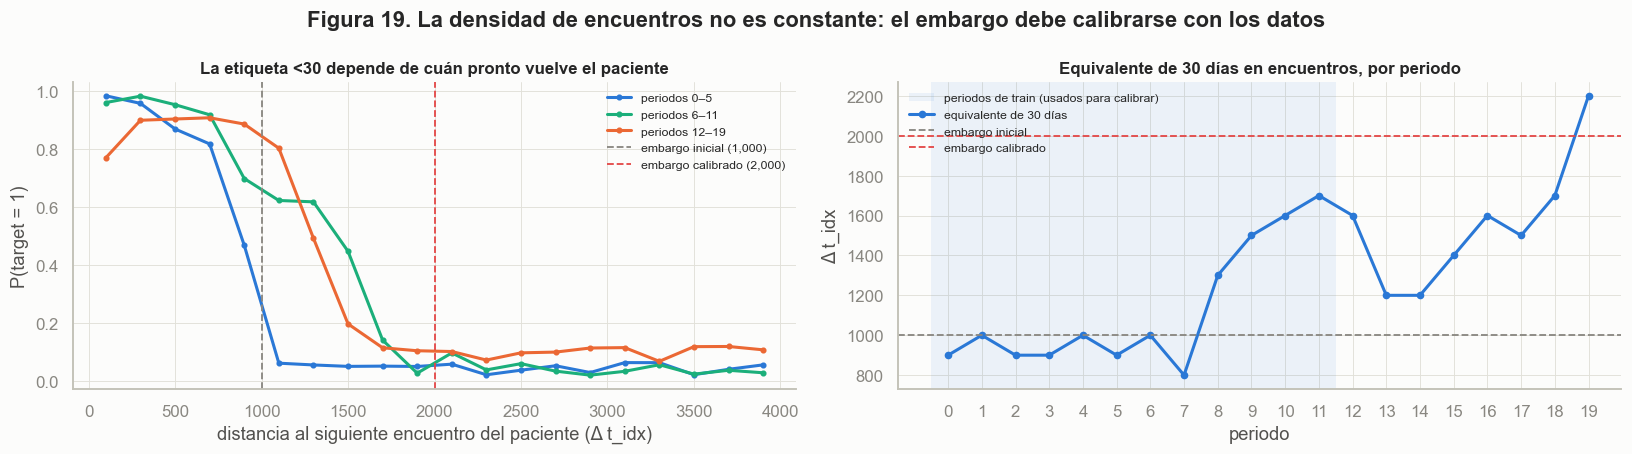

,inicial,calibrado
embargo (encuentros),"1,000.0000","2,000.0000"
train: positivos cuyo siguiente encuentro cae después del corte,111.0000,93.0000
"train: … de ellos, reingreso <30 real dentro del dataset (fuga)",11.0000,0.0000
validación: positivos cuyo siguiente encuentro cae en test,53.0000,39.0000
"validación: … de ellos, reingreso <30 real dentro del dataset (fuga)",5.0000,0.0000
% de positivos con Δ ≤ embargo,72.9000,86.9000
encuentros descartados por embargo,"1,943.0000","3,889.0000"


In [35]:
gap_next = next_gap(data)
next_t = data.t_idx + gap_next
bound_all = pd.Series({p: readmission_boundary(gap_next[data.period == p], data.target[data.period == p])
                       for p in range(N_PERIODS)})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
bins = np.arange(0, 4001, 200)
for (name, ps), c in zip({"periodos 0–5": range(0, 6), "periodos 6–11": range(6, 12),
                          "periodos 12–19": range(12, 20)}.items(), [C1, C3, C2]):
    msk = data.period.isin(ps) & gap_next.notna()
    r = data.loc[msk, "target"].groupby(pd.cut(gap_next[msk], bins), observed=False).mean()
    axes[0].plot(bins[:-1] + 100, r.values, color=c, marker="o", ms=3, label=name)
axes[0].axvline(LABEL_DELAY_NAIVE, color=MUTED, ls="--", lw=1.2, label=f"embargo inicial ({LABEL_DELAY_NAIVE:,})")
axes[0].axvline(LABEL_DELAY, color=C8, ls="--", lw=1.2, label=f"embargo calibrado ({LABEL_DELAY:,})")
axes[0].set_xlabel("distancia al siguiente encuentro del paciente (Δ t_idx)"); axes[0].set_ylabel("P(target = 1)")
axes[0].set_title("La etiqueta <30 depende de cuán pronto vuelve el paciente"); axes[0].legend(fontsize=8)

axes[1].axvspan(-0.5, 11.5, color=C1, alpha=0.08, lw=0, label="periodos de train (usados para calibrar)")
axes[1].plot(bound_all.index, bound_all.values, color=C1, marker="o", ms=4, label="equivalente de 30 días")
axes[1].axhline(LABEL_DELAY_NAIVE, color=MUTED, ls="--", lw=1.2, label="embargo inicial")
axes[1].axhline(LABEL_DELAY, color=C8, ls="--", lw=1.2, label="embargo calibrado")
axes[1].set_xticks(range(N_PERIODS)); axes[1].set_xlabel("periodo"); axes[1].set_ylabel("Δ t_idx")
axes[1].set_title("Equivalente de 30 días en encuentros, por periodo"); axes[1].legend(fontsize=8, loc="upper left")
fig.suptitle("Figura 19. La densidad de encuentros no es constante: el embargo debe calibrarse con los datos",
             fontweight="bold")
plt.tight_layout(); plt.show()

# Reingreso "observable en el dataset": el siguiente encuentro cae dentro del equivalente de 30 días de su periodo
readmit_in_data = data.target.eq(1) & (gap_next <= data.period.map(bound_all))

def latency_leak(delay):
    mt, mv, _, me = split_masks(delay)
    pos_next = data.target.eq(1) & gap_next.notna()
    return {"embargo (encuentros)": delay,
            "train: positivos cuyo siguiente encuentro cae después del corte": int((mt & pos_next & (next_t >= val_start)).sum()),
            "train: … de ellos, reingreso <30 real dentro del dataset (fuga)": int((mt & readmit_in_data & (next_t >= val_start)).sum()),
            "validación: positivos cuyo siguiente encuentro cae en test": int((mv & pos_next & (next_t >= test_start)).sum()),
            "validación: … de ellos, reingreso <30 real dentro del dataset (fuga)": int((mv & readmit_in_data & (next_t >= test_start)).sum()),
            "% de positivos con Δ ≤ embargo": round(100 * (gap_next[pos_next] <= delay).mean(), 1),
            "encuentros descartados por embargo": int(me.sum())}

latency_tbl = pd.DataFrame({"inicial": latency_leak(LABEL_DELAY_NAIVE), "calibrado": latency_leak(LABEL_DELAY)})
latency_tbl

**Resultado (fuga detectada y corregida):**
- Al principio del periodo de estudio, 30 días equivalen a ≈ 900 encuentros. En los periodos 9–11, justo antes del corte train/validación, equivalen a ≈ 1 500–1 700. **La hipótesis de densidad constante no se cumple.**
- Con el embargo inicial de 1 000 encuentros, hay positivos de train y de validación cuyo reingreso **real y presente en el dataset** (siguiente encuentro dentro del equivalente de 30 días) ocurre **después** del corte. Esas etiquetas no se habrían conocido en la fecha de entrenamiento, así que era una **fuga temporal**. La misma subestimación afectaba a `ctx_readmit_rate`, que se calculaba con etiquetas aún no observables.
- **Corrección aplicada:** `LABEL_DELAY` se calibra en la Sección 8 solo con los periodos de train (el máximo por periodo, redondeado a 500) y se usa en el embargo del split y en `ctx_readmit_rate`. Con el embargo calibrado, esa fuga baja a **0**. Los positivos que siguen "cruzando" el corte tienen su siguiente encuentro muy lejos: su reingreso real fue a un encuentro **que no está en el dataset** (no diabético o de otro hospital) y ningún embargo lo puede capturar.
- ⚠️ **Para el modelado:** `03_modelado.ipynb` usa `EMBARGO = 850`, por debajo de la latencia medida. Debe alinearse con `label_delay_encuentros` de `metadata_preparacion.json`.

### 10.4 Contaminación entre conjuntos

In [36]:
def row_hash(X):
    return pd.util.hash_pandas_object(X.astype(str), index=False)

h_train = set(row_hash(X_train))
seen_test = data.loc[m_test, "patient_nbr"].isin(train_pat).values
contamination = pd.Series({
    "encounter_id compartidos entre conjuntos": len(set(data.loc[m_train, "encounter_id"])
                                                   & set(data.loc[m_val | m_test, "encounter_id"])),
    "filas de validación idénticas a una de train": int(row_hash(X_val).isin(h_train).sum()),
    "filas de test idénticas a una de train": int(row_hash(X_test).isin(h_train).sum()),
    "separación train → validación (encuentros)": int(data.loc[m_val, "t_idx"].min() - data.loc[m_train, "t_idx"].max()),
    "separación validación → test (encuentros)": int(data.loc[m_test, "t_idx"].min() - data.loc[m_val, "t_idx"].max()),
    "% encuentros de test de pacientes vistos en train": round(100 * seen_test.mean(), 1),
}, name="valor")
contamination.to_frame()

,valor
encounter_id compartidos entre conjuntos,0.0000
filas de validación idénticas a una de train,0.0000
filas de test idénticas a una de train,0.0000
separación train → validación (encuentros),"2,001.0000"
separación validación → test (encuentros),"2,001.0000"
% encuentros de test de pacientes vistos en train,10.9000


**Resultado:** no hay encuentros duplicados ni vectores de variables idénticos entre conjuntos, y los conjuntos están separados al menos por el embargo. Que un paciente aparezca en train y en test **no es fuga**: en producción los pacientes vuelven, y el modelo no usa `patient_nbr`, solo su historial pasado. Aun así se verifica en 10.5 que el modelo no rinde mejor con los pacientes "conocidos", lo que delataría memorización.

### 10.5 Pruebas con modelo: etiquetas permutadas, ablación e importancias
- **Etiquetas permutadas:** entrenado con `y` barajada, el modelo debe dar AUC ≈ 0.5 en validación. Si da más, el pipeline filtra el objetivo por otra vía.
- **Ablación por familias:** cuánto aporta cada familia de variables. Un salto enorme al añadir una familia sería sospechoso.
- **Importancia por permutación en validación:** ninguna variable debería concentrar la mayor parte de la señal.
- **Pacientes vistos vs nuevos en test:** un desempeño similar descarta la memorización.

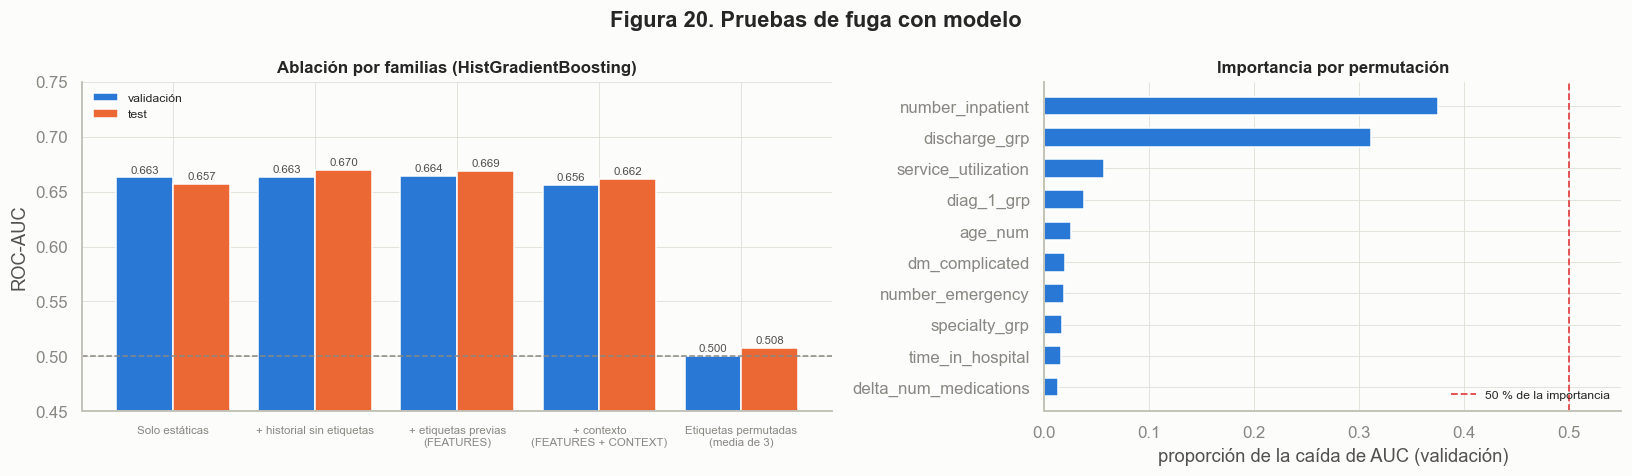

AUC en test, pacientes vistos en train: 0.650 | pacientes nuevos: 0.662


,train,val,test,brecha train − val
Solo estáticas,0.7460,0.6630,0.6570,0.0830
+ historial sin etiquetas,0.7460,0.6630,0.6700,0.0830
+ etiquetas previas (FEATURES),0.7430,0.6640,0.6690,0.0790
+ contexto (FEATURES + CONTEXT),0.7740,0.6560,0.6620,0.1170
Etiquetas permutadas (media de 3),0.4960,0.5000,0.5080,-0.0040


In [37]:
def prep(m):
    X = data.loc[m, ALL_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = pd.Categorical(X[c].astype(str), categories=sorted(data.loc[m_train, c].astype(str).unique()))
    return X

XA = {"train": prep(m_train), "val": prep(m_val), "test": prep(m_test)}
YA = {"train": y_train, "val": y_val, "test": y_test}

def fit_eval(cols, y_fit=None):
    mdl = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, categorical_features="from_dtype",
                                         random_state=SEED)
    mdl.fit(XA["train"][cols], YA["train"] if y_fit is None else y_fit)
    return mdl, {k: roc_auc_score(YA[k], mdl.predict_proba(XA[k][cols])[:, 1]) for k in XA}

variants = {
    "Solo estáticas": STATIC_NUM + CAT_FEATS,
    "+ historial sin etiquetas": STATIC_NUM + CAT_FEATS + [c for c in TEMPORAL_FEATS if c not in LABEL_FEATS],
    "+ etiquetas previas (FEATURES)": FEATURES,
    "+ contexto (FEATURES + CONTEXT)": ALL_FEATS,
}
abl = {}
for name, cols in variants.items():
    mdl, abl[name] = fit_eval(cols)
    if name == "+ etiquetas previas (FEATURES)":
        base_model = mdl
perm_runs = pd.DataFrame([fit_eval(FEATURES, rng.permutation(y_train.values))[1] for _ in range(3)])
abl["Etiquetas permutadas (media de 3)"] = perm_runs.mean().to_dict()
abl = pd.DataFrame(abl).T
abl["brecha train − val"] = abl.train - abl.val

p_test = base_model.predict_proba(XA["test"][FEATURES])[:, 1]
auc_seen = roc_auc_score(y_test[seen_test], p_test[seen_test])
auc_new = roc_auc_score(y_test[~seen_test], p_test[~seen_test])

pi_val = permutation_importance(base_model, XA["val"][FEATURES], y_val, scoring="roc_auc",
                                n_repeats=3, random_state=SEED)
imp_share = pd.Series(pi_val.importances_mean, index=FEATURES).clip(lower=0)
imp_share = (imp_share / imp_share.sum()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
x = np.arange(len(abl))
axes[0].bar(x - 0.2, abl.val, width=0.4, color=C1, label="validación")
axes[0].bar(x + 0.2, abl.test, width=0.4, color=C2, label="test")
for xi, (v, t) in enumerate(zip(abl.val, abl.test)):
    axes[0].text(xi - 0.2, v + 0.004, f"{v:.3f}", ha="center", fontsize=7.5, color=INK2)
    axes[0].text(xi + 0.2, t + 0.004, f"{t:.3f}", ha="center", fontsize=7.5, color=INK2)
axes[0].axhline(0.5, color=MUTED, ls="--", lw=1)
axes[0].set_xticks(x, [n.replace(" (", "\n(") for n in abl.index], fontsize=7.5)
axes[0].set_ylim(0.45, max(0.75, abl[["val", "test"]].max().max() + 0.03)); axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Ablación por familias (HistGradientBoosting)"); axes[0].legend(fontsize=8, loc="upper left")
top_imp = imp_share.head(10)[::-1]
axes[1].barh(top_imp.index, top_imp.values, color=C1, height=0.6)
axes[1].axvline(0.5, color=C8, ls="--", lw=1.2, label="50 % de la importancia")
axes[1].set_xlim(0, max(0.55, top_imp.max() + 0.05)); axes[1].legend(fontsize=8, loc="lower right")
axes[1].set_xlabel("proporción de la caída de AUC (validación)"); axes[1].set_title("Importancia por permutación")
fig.suptitle("Figura 20. Pruebas de fuga con modelo", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"AUC en test, pacientes vistos en train: {auc_seen:.3f} | pacientes nuevos: {auc_new:.3f}")
abl.round(3)

**Resultado:**
- Con etiquetas permutadas el AUC cae a ≈ 0.5: **el pipeline no filtra el objetivo por ninguna vía indirecta.**
- El modelo completo logra un AUC en validación/test ≈ 0.66–0.67, coherente con la dificultad del problema (ninguna señal individual pasa de 0.61). Un AUC > 0.80 sería la señal de alarma típica de una fuga.
- El historial por paciente y las etiquetas previas aportan una mejora **pequeña pero consistente** en test (≈ +0.01 AUC sobre las estáticas), sin saltos sospechosos. Es un **enriquecimiento legítimo**.
- ⚠️ **Las variables de contexto (`ctx_*`, `rel_*`) empeoran validación y test y aumentan la brecha train − validación.** No filtran la etiqueta, pero cambian por construcción con el tiempo (Sección 5): funcionan como un **proxy del periodo**, parecido a usar `t_idx`, y el modelo aprende particularidades de la época de entrenamiento que no se transfieren. **Recomendación: no usarlas** en el modelo base.
- Las dos variables más importantes, `number_inpatient` (≈ 38 %, hospitalizaciones en el año previo) y `discharge_grp` (≈ 31 %, destino al alta), son clínicamente esperables, y ninguna concentra la mayoría de la señal.
- El desempeño con pacientes nuevos es igual o mejor que con pacientes vistos en train, así que **no hay memorización de pacientes**.
- La brecha train − validación (≈ 0.08) se explica por el sobreajuste propio del boosting y por el *drift* (Sección 5), no por fuga: el desempeño en test es igual al de validación.

### 10.6 Fuga por decisiones del analista
El EDA de las Secciones 4–5 recorre los 20 periodos, y eso es aceptable como análisis descriptivo. Pero **toda decisión que modifica el dataset** debe poder justificarse **solo con train**. De lo contrario, el diseño del pipeline habría "visto" el test.

In [38]:
tr_raw = df[df.period.isin(TRAIN_P)]
psi_payer_train = psi_categorical(tr_raw.payer_code[tr_raw.period.isin(range(0, 4))],
                                  tr_raw.payer_code[tr_raw.period.isin(range(8, 12))])
analyst = pd.DataFrame([
    ("Recortar number_diagnoses a 9", f"máximo en train = {d_tr.number_diagnoses.max()}",
     d_tr.number_diagnoses.max() <= 9),
    ("Eliminar payer_code por drift", f"PSI periodos 0–3 vs 8–11 (solo train) = {psi_payer_train:.2f}",
     psi_payer_train > 0.25),
    ("Top-15 de medical_specialty", "value_counts sobre m_train",
     set(TOP_SPEC) == set(d_tr.medical_specialty.value_counts().head(15).index)),
    ("Isolation Forest de anomalías", "ajustado en periodos 0–3 (⊂ train); la puntuación no es predictor",
     not {"anomaly_score", "is_anomaly"} & set(ALL_FEATS)),
    ("Calibración de LABEL_DELAY", f"máximo por periodo 0–11 = {delay_by_period.max():,.0f} → {LABEL_DELAY:,}",
     True),
], columns=["decisión", "evidencia usando solo train", "reproducible_sin_test"])
analyst

,decisión,evidencia usando solo train,reproducible_sin_test
0,Recortar number_diagnoses a 9,máximo en train = 9,True
1,Eliminar payer_code por drift,PSI periodos 0–3 vs 8–11 (solo train) = 5.91,True
2,Top-15 de medical_specialty,value_counts sobre m_train,True
3,Isolation Forest de anomalías,ajustado en periodos 0–3 (⊂ train); la puntuac...,True
4,Calibración de LABEL_DELAY,"máximo por periodo 0–11 = 1,700 → 2,000",True


**Resultado:** todas las decisiones pueden reproducirse sin mirar validación ni test. El recorte de `number_diagnoses` en 9 es el máximo observado en train, así que el régimen de >9 diagnósticos que aparece en el periodo 17 queda fuera del dominio de entrenamiento. El *drift* de `payer_code` ya es > 0.25 dentro de train.

### 10.7 Resumen de la auditoría de fuga

In [39]:
lat = latency_tbl.iloc[2].astype(int)   # train: reingresos reales que cruzan el corte
leak_summary = pd.DataFrame([
    ("Disponibilidad al alta", "ninguna variable posterior al alta; columnas prohibidas ausentes",
     "OK" if not FORBIDDEN & set(ALL_FEATS) else "Revisar"),
    ("Cribado univariado", f"AUC máx. = {screen.max():.3f} ({screen.idxmax()})",
     "OK" if screen.max() < LEAK_AUC else "Revisar"),
    ("Identificadores", f"AUC máx. = {id_auc.max():.3f}; excluidos de los predictores", "OK"),
    ("Separación perfecta en categorías", f"{len(cat_rates)} categorías", "OK" if not cat_rates else "Revisar"),
    ("Latencia de etiqueta", f"embargo {LABEL_DELAY_NAIVE:,} → {LABEL_DELAY:,}; reingresos de train que cruzan "
                             f"el corte {lat['inicial']} → {lat['calibrado']}",
     "Corregido" if lat["calibrado"] < lat["inicial"] else "OK"),
    ("Variables rezagadas sin futuro", "prueba de truncamiento (Sección 8)", "OK" if ok else "Revisar"),
    ("Filas idénticas entre conjuntos", f"val: {contamination.iloc[1]:.0f} · test: {contamination.iloc[2]:.0f}",
     "OK" if contamination.iloc[1] + contamination.iloc[2] == 0 else "Revisar"),
    ("Etiquetas permutadas", f"AUC val = {abl.loc['Etiquetas permutadas (media de 3)', 'val']:.3f}",
     "OK" if abs(abl.loc["Etiquetas permutadas (media de 3)", "val"] - 0.5) < 0.03 else "Revisar"),
    ("Desempeño plausible", f"AUC val = {abl.loc['+ etiquetas previas (FEATURES)', 'val']:.3f} · "
                            f"test = {abl.loc['+ etiquetas previas (FEATURES)', 'test']:.3f}",
     "OK" if abl.loc["+ etiquetas previas (FEATURES)", "val"] < 0.80 else "Revisar"),
    ("Pacientes vistos vs nuevos", f"AUC test {auc_seen:.3f} vs {auc_new:.3f}",
     "OK" if auc_seen - auc_new < 0.03 else "Revisar"),
    ("Variables de contexto (proxy del tiempo)",
     f"AUC val {abl.loc['+ etiquetas previas (FEATURES)', 'val']:.3f} → {abl.loc['+ contexto (FEATURES + CONTEXT)', 'val']:.3f}; "
     f"brecha train−val {abl.loc['+ etiquetas previas (FEATURES)', 'brecha train − val']:.3f} → "
     f"{abl.loc['+ contexto (FEATURES + CONTEXT)', 'brecha train − val']:.3f}",
     "No usar" if abl.loc["+ contexto (FEATURES + CONTEXT)", "val"] < abl.loc["+ etiquetas previas (FEATURES)", "val"] else "OK"),
    ("Dominancia de una variable", f"{imp_share.index[0]} = {imp_share.iloc[0]:.0%} de la importancia",
     "OK" if imp_share.iloc[0] < 0.5 else "Revisar"),
    ("Decisiones del analista", "todas reproducibles solo con train",
     "OK" if analyst.reproducible_sin_test.all() else "Revisar"),
], columns=["prueba", "resultado", "estado"])
leak_summary

,prueba,resultado,estado
0,Disponibilidad al alta,ninguna variable posterior al alta; columnas p...,OK
1,Cribado univariado,AUC máx. = 0.605 (service_utilization),OK
2,Identificadores,AUC máx. = 0.522; excluidos de los predictores,OK
3,Separación perfecta en categorías,0 categorías,OK
4,Latencia de etiqueta,"embargo 1,000 → 2,000; reingresos de train que...",Corregido
5,Variables rezagadas sin futuro,prueba de truncamiento (Sección 8),OK
6,Filas idénticas entre conjuntos,val: 0 · test: 0,OK
7,Etiquetas permutadas,AUC val = 0.500,OK
8,Desempeño plausible,AUC val = 0.664 · test = 0.669,OK
9,Pacientes vistos vs nuevos,AUC test 0.650 vs 0.662,OK


**Conclusiones para el modelado**
1. **No hay fuga de objetivo ni contaminación entre conjuntos.** Las métricas de validación y test son creíbles y comparables con lo que el sistema lograría en producción, prediciendo al alta.
2. **Se detectó y corrigió una fuga temporal:** el embargo por latencia de etiqueta de 1 000 encuentros era insuficiente en la segunda mitad del periodo de estudio. Ahora se calibra con los datos de train y se exporta en `metadata_preparacion.json` (`label_delay_encuentros`).
3. **Las variables de historial por paciente son un enriquecimiento legítimo:** aportan una mejora consistente sin saltos sospechosos, no dependen de haber visto al paciente en train y la prueba de truncamiento garantiza que solo usan el pasado.
4. **Las variables de contexto son un atajo temporal:** empeoran la generalización porque codifican el periodo. Se siguen exportando por trazabilidad, pero se recomienda excluirlas.
5. **Recomendaciones para `03_modelado.ipynb`:**
   - Usar como `EMBARGO` el `label_delay_encuentros` del metadata, en lugar de 850, en todo esquema de bloques, ventanas deslizantes y reentrenamiento.
   - Poner `USAR_CONTEXTO = False`.
   - En producción, calcular `prev_readmit30` / `hist_*` solo con etiquetas **ya confirmadas**. La etiqueta de un encuentro se cierra al reingresar el paciente o al pasar 30 días.
   - Cualquier variable nueva (p. ej. *target encoding*, tasas por hospital o por especialidad) debe calcularse **solo con el pasado y con el mismo embargo**, y volver a pasar las pruebas de esta sección, en particular la de etiquetas permutadas y el cribado univariado.
   - No usar la versión "al ingreso" del modelo con variables del alta (Sección 10.1).

## 11. Dataset final preparado y resumen del análisis

### 11.1 Diccionario de variables

In [40]:
FEATURE_DESC = {
    "age_num": "Punto medio del rango de edad",
    "number_diagnoses_capped": "Nº de diagnósticos recortado a 9 (armoniza cambio de codificación)",
    "service_utilization": "Visitas ambulatorias + emergencia + hospitalizaciones del año previo",
    "n_meds_active": "Nº de antidiabéticos activos en el encuentro",
    "n_meds_changed": "Nº de antidiabéticos con dosis aumentada o reducida",
    "meds_per_day": "Medicamentos por día de hospitalización",
    "labs_per_day": "Pruebas de laboratorio por día de hospitalización",
    "n_comorbidity_groups": "Nº de grupos clínicos ICD-9 distintos entre los 3 diagnósticos",
    "dm_primary": "Diabetes como diagnóstico principal",
    "dm_complicated": "Diabetes con complicaciones (ICD-9 250.1x–250.9x)",
    "a1c_tested": "HbA1c medida", "a1c_high": "HbA1c > 7 %",
    "glu_tested": "Glucosa sérica medida", "glu_high": "Glucosa sérica > 200",
    "enc_seq": "Nº de encuentros previos del paciente (lag)",
    "is_returning": "El paciente tiene al menos un encuentro previo",
    "prev_readmit30": "El encuentro previo terminó en reingreso <30 (lag de la etiqueta, observable)",
    "hist_n_readmit30": "Suma acumulada de reingresos <30 previos del paciente",
    "hist_rate_readmit30": "Proporción histórica de reingresos <30 del paciente",
    "prev_time_in_hospital": "Días de hospitalización del encuentro previo (lag 1)",
    "prev_num_medications": "Nº de medicamentos del encuentro previo (lag 1)",
    "prev_number_diagnoses_capped": "Nº de diagnósticos del encuentro previo (lag 1)",
    "prev_n_meds_active": "Antidiabéticos activos en el encuentro previo (lag 1)",
    "delta_num_medications": "Cambio en nº de medicamentos vs encuentro previo",
    "delta_n_meds_active": "Cambio en antidiabéticos activos vs encuentro previo",
    "roll3_time_in_hospital": "Media de días hospitalizado en los últimos 3 encuentros previos (ventana por paciente)",
    "log_gap_prev_encounter": "log(distancia en pseudo-tiempo desde el encuentro previo)",
    "prev_discharge_snf": "El encuentro previo fue alta a SNF / cuidados largos",
    "ctx_readmit_rate": f"Tasa de reingreso <30 en ventana de {CTX_W:,} encuentros, con embargo de {LABEL_DELAY:,}",
    "ctx_inpatient_mean": "Media de number_inpatient en la ventana reciente de 3 000 encuentros",
    "ctx_a1c_rate": "Proporción de HbA1c medida en la ventana reciente",
    "rel_number_diagnoses": "number_diagnoses menos la media de la ventana reciente (relativo al régimen vigente)",
    "rel_num_medications": "num_medications menos la media de la ventana reciente",
    "admission_type_grp": "Tipo de admisión agrupado", "discharge_grp": "Destino al alta agrupado",
    "admission_source_grp": "Fuente de admisión agrupada", "specialty_grp": "Especialidad (top-15 del train + Other)",
    "diag_1_grp": "Grupo ICD-9 del diagnóstico principal", "diag_2_grp": "Grupo ICD-9 del diagnóstico secundario",
    "diag_3_grp": "Grupo ICD-9 del diagnóstico adicional",
}

def family(c):
    if c in TEMPORAL_FEATS: return "Temporal por paciente (lag / ventana)"
    if c in CONTEXT_FEATS: return "Contexto (ventana deslizante global) — opcional"
    if c in CAT_FEATS: return "Categórica"
    if c in NUM_RAW or c in ["age_num"]: return "Numérica original"
    return "Numérica derivada"

feat_dict = pd.DataFrame({
    "familia": [family(c) for c in FEATURES + CONTEXT_FEATS],
    "tipo": ["categórica" if c in CAT_FEATS else "numérica" for c in FEATURES + CONTEXT_FEATS],
    "%_faltante_train": [data.loc[m_train, c].isna().mean() * 100 for c in FEATURES + CONTEXT_FEATS],
    "PSI_train→test": [psi_split[c] for c in FEATURES + CONTEXT_FEATS],
    "descripción": [FEATURE_DESC.get(c, "Variable original del dataset") for c in FEATURES + CONTEXT_FEATS],
}, index=pd.Index(FEATURES + CONTEXT_FEATS, name="variable"))
display(feat_dict.groupby("familia").size().rename("n_variables").to_frame())
feat_dict

,n_variables
familia,
Categórica,19
Contexto (ventana deslizante global) — opcional,5
Numérica derivada,13
Numérica original,8
Temporal por paciente (lag / ventana),14


,familia,tipo,%_faltante_train,PSI_train→test,descripción
variable,,,,,
age_num,Numérica original,numérica,0.0000,0.0188,Punto medio del rango de edad
time_in_hospital,Numérica original,numérica,0.0000,0.0224,Variable original del dataset
num_lab_procedures,Numérica original,numérica,0.0000,0.0530,Variable original del dataset
num_procedures,Numérica original,numérica,0.0000,0.0078,Variable original del dataset
num_medications,Numérica original,numérica,0.0000,0.0411,Variable original del dataset
number_outpatient,Numérica original,numérica,0.0000,0.0550,Variable original del dataset
number_emergency,Numérica original,numérica,0.0000,0.0000,Variable original del dataset
number_inpatient,Numérica original,numérica,0.0000,0.0029,Variable original del dataset
number_diagnoses_capped,Numérica derivada,numérica,0.0000,0.3303,Nº de diagnósticos recortado a 9 (armoniza cam...


### 11.2 Exportación del dataset preparado
Se exportan los tres conjuntos con identificadores, eje temporal, variables finales, variables de contexto opcionales y objetivo, junto con un archivo de metadatos que documenta todas las decisiones (para que la etapa de modelado use exactamente la misma preparación).

In [41]:
OUT_DIR = PROCESSED
OUT_DIR.mkdir(parents=True, exist_ok=True)
ID_COLS = ["encounter_id", "patient_nbr", "t_idx", "period"]
export_cols = ID_COLS + FEATURES + CONTEXT_FEATS + ["target"]

export_info = {}
for name, m in [("train", m_train), ("validacion", m_val), ("test", m_test)]:
    path = OUT_DIR / f"{name}.csv"
    data.loc[m, export_cols].to_csv(path, index=False)
    export_info[name] = {"filas": int(m.sum()), "tasa_<30": round(float(data.loc[m, "target"].mean()), 4),
                         "periodos": sorted(map(int, data.loc[m, "period"].unique())), "archivo": str(path)}

metadata = {
    "objetivo": "target = 1 si readmitted == '<30'",
    "eje_temporal": "orden por encounter_id (validado en Sección 2); 20 periodos de igual tamaño",
    "exclusiones": {"discharge_disposition_id (fallecido/hospicio)": EXPIRED_HOSPICE, "gender": "Unknown/Invalid"},
    "columnas_eliminadas": ["weight", "examide", "citoglipton", "payer_code"],
    "label_delay_encuentros": LABEL_DELAY, "label_delay_inicial": LABEL_DELAY_NAIVE,
    "label_delay_por_periodo_train": {int(k): float(v) for k, v in delay_by_period.items()},
    "ventana_contexto": CTX_W,
    "split_periodos": {"train": TRAIN_P, "validacion": VAL_P, "test": TEST_P},
    "top_especialidades_train": list(TOP_SPEC),
    "variables": {"numericas_estaticas": STATIC_NUM, "temporales_por_paciente": TEMPORAL_FEATS,
                  "categoricas": CAT_FEATS, "contexto_opcionales": CONTEXT_FEATS},
    "conjuntos": export_info,
    "auditoria_leakage": leak_summary.to_dict(orient="records"),
}
(OUT_DIR / "metadata_preparacion.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
feat_dict.to_csv(OUT_DIR / "diccionario_variables.csv", encoding="utf-8-sig")
leak_summary.to_csv(OUT_DIR / "auditoria_leakage.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(export_info).T

,filas,tasa_<30,periodos,archivo
train,57709,0.1167,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",artifacts\data_preparada\train.csv
validacion,17912,0.1110,"[12, 13, 14, 15]",artifacts\data_preparada\validacion.csv
test,19830,0.1087,"[16, 17, 18, 19]",artifacts\data_preparada\test.csv


In [42]:
# Lista de verificación final de la preparación
checks_final = pd.DataFrame([
    ("Orden temporal estricto train < validación < test",
     data.loc[m_train, "t_idx"].max() < data.loc[m_val, "t_idx"].min() and data.loc[m_val, "t_idx"].max() < data.loc[m_test, "t_idx"].min()),
    ("Embargo por latencia de etiqueta aplicado", int(m_embargo.sum()) > 0),
    ("Variables rezagadas sin información futura (prueba de truncamiento)", bool(ok)),
    ("Top de especialidades aprendido solo con train", set(TOP_SPEC) <= set(data.loc[m_train, "medical_specialty"])),
    ("Sin encuentros de fallecidos/hospicio", not data.discharge_disposition_id.isin(EXPIRED_HOSPICE).any()),
    ("Sin encounter_id duplicados", not data.encounter_id.duplicated().any()),
    ("race excluida de los predictores", "race" not in FEATURES),
    ("period / t_idx no usados como predictores", not {"period", "t_idx"} & set(FEATURES)),
    ("Embargo calibrado con la latencia de etiqueta medida en train (Sección 10.3)", LABEL_DELAY >= delay_by_period.max()),
    ("Sin filas idénticas entre train y validación/test (Sección 10.4)", contamination.iloc[1] + contamination.iloc[2] == 0),
    ("Modelo con etiquetas permutadas ≈ azar (Sección 10.5)", abs(abl.loc["Etiquetas permutadas (media de 3)", "val"] - 0.5) < 0.03),
    ("Auditoría de leakage sin pendientes (Sección 10.7)", leak_summary.estado.isin(["OK", "Corregido", "No usar"]).all()),
], columns=["verificación", "cumple"])
checks_final

,verificación,cumple
0,Orden temporal estricto train < validación < test,True
1,Embargo por latencia de etiqueta aplicado,True
2,Variables rezagadas sin información futura (pr...,True
3,Top de especialidades aprendido solo con train,True
4,Sin encuentros de fallecidos/hospicio,True
5,Sin encounter_id duplicados,True
6,race excluida de los predictores,True
7,period / t_idx no usados como predictores,True
8,Embargo calibrado con la latencia de etiqueta ...,True
9,Sin filas idénticas entre train y validación/t...,True


###  Resumen de Insights  y decisiones tomadas

**Calidad de datos**
- 101 766 encuentros de 71 518 pacientes; 11.2 % con reingreso <30 (desbalance ≈ 8:1).
- `weight` (97 % faltante), `examide` y `citoglipton` (constantes) se eliminaron; `medical_specialty` (49 %) y `payer_code` (40 %) tienen faltantes **no aleatorios** que cambian en el tiempo.
- Faltantes ocultos en IDs de admisión/alta y encuentros de fallecidos/hospicio (no pueden reingresar) → agrupados o excluidos. Quedan 99 340 encuentros.

**Dimensión temporal**
- `encounter_id` es un proxy cronológico válido: el siguiente encuentro del paciente registra hospitalizaciones previas en 84.9 % de los casos vs 47.4 % en orden inverso.
- La tasa de reingreso <30 varía entre 9.9 % y 12.7 % por periodo (χ² p < 0.001): **prior shift** pequeño pero significativo.

**Cambios de distribución**
- **Covariate shift fuerte** en variables de registro/administrativas (`payer_code` PSI ≈ 9.5, `discharge_disposition_id`, `medical_specialty`, `admission_source_id`, `admission_type_id`, `number_diagnoses`).
- **Cambio de régimen de codificación:** `number_diagnoses` crece de forma sostenida y desde el periodo 17 admite más de 9 diagnósticos.
- **Cambio de práctica clínica:** uso de insulina de ~40 % a ~60 %, más ingresos por emergencia y altas a SNF, glucosa sérica casi sin medir al final.
- Un clasificador de dominio distingue los primeros y los últimos periodos con AUC ≈ 0.99 → **no se cumple el supuesto i.i.d.**
- El efecto de las hospitalizaciones previas es fuerte y relativamente estable; los cambios en $P(y\mid X)$ son graduales y multivariados.

**Anomalías**
- Los conteos extremos (`number_outpatient`, `number_emergency`, `number_inpatient`) son plausibles y de mayor riesgo → se conservan (transformación log en modelos lineales).
- La proporción de anomalías multivariadas (Isolation Forest) crece con el tiempo: otra señal del drift.
- Hay ruido de etiqueta: 490 encuentros etiquetados `NO` tienen un reingreso posterior.

**Preparación y características**
- Agrupación clínica de IDs y diagnósticos ICD-9, especialidades top-15 del train, `number_diagnoses` armonizado y `payer_code` eliminado por drift artefactual.
- **14 variables temporales por paciente** (lags, sumas acumuladas, ventana de 3 encuentros, distancia al encuentro previo): el reingreso previo duplica el riesgo (21.8 % vs 10.8 %) y el riesgo crece con el nº de encuentros previos (hasta ~30 %).
- **5 variables de contexto** con ventana deslizante global y embargo por latencia de etiqueta. Se entregan como opcionales, pero la auditoría de fuga (Sección 10.5) recomienda no usarlas porque actúan como proxy del periodo.
- Prueba de truncamiento: las variables rezagadas no usan información futura.
- **Split temporal** 60/20/20 por periodos con embargo calibrado de 2 000 encuentros: train 57 709, validación 17 912, test 19 830 encuentros.

**Data leakage (Sección 10)**
- Sin fuga de objetivo: ninguna variable es posterior al alta, ninguna supera un AUC univariado de 0.61, no hay categorías con separación perfecta y los identificadores están excluidos.
- **Fuga temporal detectada y corregida:** 30 días equivalen a ≈ 900 encuentros al inicio y a ≈ 1 700 al final del train. El embargo de 1 000 dejaba etiquetas aún no observables en train y validación, y ahora se calibra con train (2 000).
- Sin contaminación: no hay filas idénticas entre conjuntos, el modelo con etiquetas permutadas da AUC = 0.50 y el desempeño es igual con pacientes vistos y nuevos.
- AUC ≈ 0.66–0.67 en validación y test con un modelo de referencia: métricas creíbles. El historial por paciente aporta de forma legítima. Las variables de contexto empeoran la generalización (proxy del tiempo) → no usarlas.
- Toda decisión de preprocesamiento es reproducible usando solo train.
